In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import cross_val_score
import xgboost as xgb

print("✅ Libraries loaded")

✅ Libraries loaded


In [4]:
path = "../data/processed/"

X_train = np.load(path + "X_train.npy")
X_val   = np.load(path + "X_val.npy")
X_test  = np.load(path + "X_test.npy")
y_train = np.load(path + "y_train.npy")
y_val   = np.load(path + "y_val.npy")
y_test  = np.load(path + "y_test.npy")

X_train_m = np.load(path + "X_train_multi.npy")
X_test_m  = np.load(path + "X_test_multi.npy")
y_train_m = np.load(path + "y_train_multi.npy")
y_test_m  = np.load(path + "y_test_multi.npy")

le = joblib.load("../models/saved/label_encoder.pkl")

print(f"✅ Data loaded")
print(f"  Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")
print(f"  Multi-class train: {X_train_m.shape} | test: {X_test_m.shape}")

✅ Data loaded
  Train : (1062575, 40) | Val : (227695, 40) | Test : (227695, 40)
  Multi-class train: (1787170, 40) | test: (446793, 40)


In [5]:
print("Training Random Forest (binary)...")
print("This will take 3-6 minutes...\n")

rf_binary = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_binary.fit(X_train, y_train)
print("\n✅ Random Forest (binary) trained!")

Training Random Forest (binary)...
This will take 3-6 minutes...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  2.5min



✅ Random Forest (binary) trained!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  7.1min finished


In [6]:
y_pred_val  = rf_binary.predict(X_val)
y_prob_val  = rf_binary.predict_proba(X_val)[:, 1]

acc  = accuracy_score(y_val, y_pred_val)
f1   = f1_score(y_val, y_pred_val)
prec = precision_score(y_val, y_pred_val)
rec  = recall_score(y_val, y_pred_val)
auc  = roc_auc_score(y_val, y_prob_val)

print("=" * 50)
print("  BINARY CLASSIFICATION — Validation Results")
print("=" * 50)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")
print(f"  ROC-AUC   : {auc*100:.2f}%")
print("=" * 50)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.5s finished


  BINARY CLASSIFICATION — Validation Results
  Accuracy  : 99.71%
  Precision : 99.51%
  Recall    : 99.71%
  F1 Score  : 99.61%
  ROC-AUC   : 100.00%


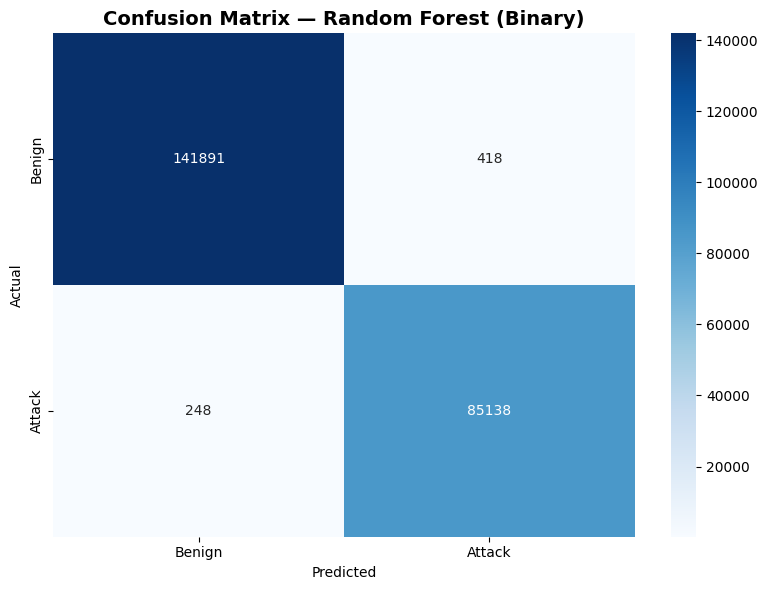

  True Negatives  (Benign correctly identified) : 141,891
  False Positives (Benign misclassified)        : 418
  False Negatives (Attacks missed!)             : 248
  True Positives  (Attacks caught!)             : 85,138


In [7]:
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title("Confusion Matrix — Random Forest (Binary)", fontsize=14, fontweight='bold')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../reports/rf_binary_confusion.png", dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"  True Negatives  (Benign correctly identified) : {tn:,}")
print(f"  False Positives (Benign misclassified)        : {fp:,}")
print(f"  False Negatives (Attacks missed!)             : {fn:,}")
print(f"  True Positives  (Attacks caught!)             : {tp:,}")

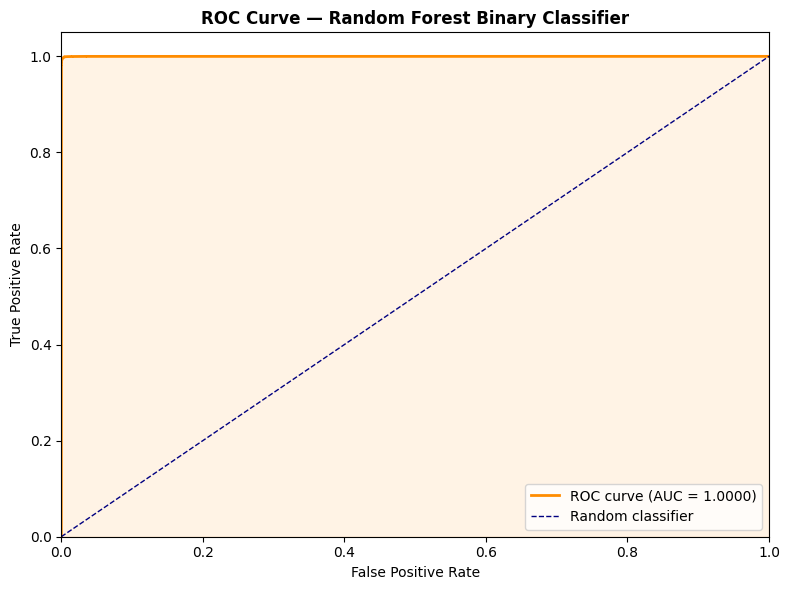

In [8]:
fpr, tpr, thresholds = roc_curve(y_val, y_prob_val)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest Binary Classifier', fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../reports/rf_roc_curve.png", dpi=150)
plt.show()

In [9]:
print("Training XGBoost (binary)...")

xgb_binary = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42,
    verbosity=1
)

xgb_binary.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=10
)

print("\n✅ XGBoost (binary) trained!")

Training XGBoost (binary)...
[0]	validation_0-logloss:0.62258
[10]	validation_0-logloss:0.19622
[20]	validation_0-logloss:0.07787
[30]	validation_0-logloss:0.03663
[40]	validation_0-logloss:0.01996
[50]	validation_0-logloss:0.01401
[60]	validation_0-logloss:0.01138
[70]	validation_0-logloss:0.00999
[80]	validation_0-logloss:0.00932
[90]	validation_0-logloss:0.00857
[99]	validation_0-logloss:0.00792

✅ XGBoost (binary) trained!


=== Model Comparison (Validation Set) ===
               Accuracy  F1 Score  Precision  Recall  ROC-AUC
Model                                                        
Random Forest     99.71     99.61      99.51   99.71    100.0
XGBoost           99.72     99.62      99.35   99.89    100.0


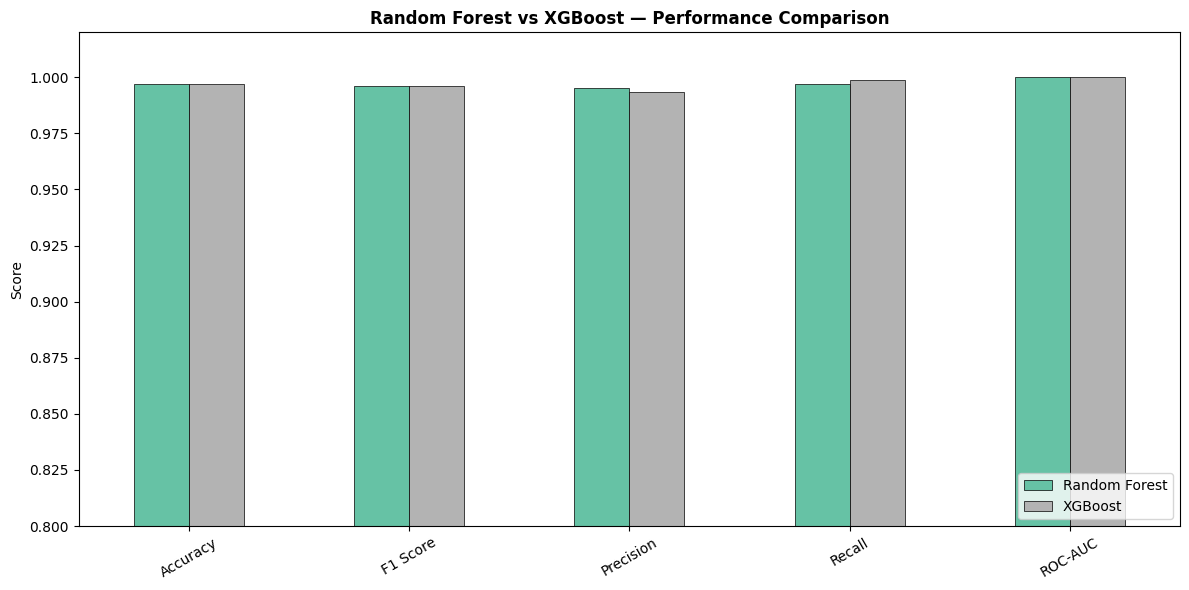

In [10]:
y_pred_xgb  = xgb_binary.predict(X_val)
y_prob_xgb  = xgb_binary.predict_proba(X_val)[:, 1]

results = {
    'Model'     : ['Random Forest', 'XGBoost'],
    'Accuracy'  : [accuracy_score(y_val, y_pred_val),  accuracy_score(y_val, y_pred_xgb)],
    'F1 Score'  : [f1_score(y_val, y_pred_val),        f1_score(y_val, y_pred_xgb)],
    'Precision' : [precision_score(y_val, y_pred_val), precision_score(y_val, y_pred_xgb)],
    'Recall'    : [recall_score(y_val, y_pred_val),    recall_score(y_val, y_pred_xgb)],
    'ROC-AUC'   : [roc_auc_score(y_val, y_prob_val),   roc_auc_score(y_val, y_prob_xgb)],
}

results_df = pd.DataFrame(results).set_index('Model')
print("=== Model Comparison (Validation Set) ===")
print((results_df * 100).round(2).to_string())

# Bar chart
results_df.T.plot(kind='bar', figsize=(12, 6), colormap='Set2', edgecolor='black', linewidth=0.5)
plt.title("Random Forest vs XGBoost — Performance Comparison", fontweight='bold')
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.ylim(0.8, 1.02)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("../reports/rf_vs_xgb_comparison.png", dpi=150)
plt.show()

In [11]:
print("Training Random Forest (multi-class — 15 attack types)...")
print("This will take 5-8 minutes...\n")

rf_multi = RandomForestClassifier(
    n_estimators=100,
    max_depth=25,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_multi.fit(X_train_m, y_train_m)
print("\n✅ Random Forest (multi-class) trained!")

Training Random Forest (multi-class — 15 attack types)...
This will take 5-8 minutes...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  2.2min



✅ Random Forest (multi-class) trained!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  6.4min finished


In [12]:
y_pred_multi = rf_multi.predict(X_test_m)

print("=== Multi-class Classification Report ===\n")
print(classification_report(
    y_test_m, y_pred_multi,
    target_names=le.classes_,
    digits=4
))

overall_acc = accuracy_score(y_test_m, y_pred_multi)
overall_f1  = f1_score(y_test_m, y_pred_multi, average='weighted')
print(f"Overall Accuracy : {overall_acc*100:.2f}%")
print(f"Weighted F1      : {overall_f1*100:.2f}%")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    1.9s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    5.0s finished


=== Multi-class Classification Report ===

                            precision    recall  f1-score   support

                    BENIGN     0.9998    0.9943    0.9970    379492
                       Bot     0.1771    0.9861    0.3002       288
                      DDoS     0.9995    0.9995    0.9995     25603
             DoS GoldenEye     0.9966    0.9971    0.9968      2057
                  DoS Hulk     0.9902    0.9987    0.9945     34570
          DoS Slowhttptest     0.9437    0.9933    0.9679      1046
             DoS slowloris     0.9972    0.9972    0.9972      1077
               FTP-Patator     0.9958    0.9983    0.9971      1187
                Heartbleed     1.0000    1.0000    1.0000         2
              Infiltration     1.0000    0.7143    0.8333         7
                  PortScan     0.9016    0.9821    0.9402       392
               SSH-Patator     0.9969    0.9922    0.9946       644
  Web Attack � Brute Force     0.7586    0.5986    0.6692       294
Web 

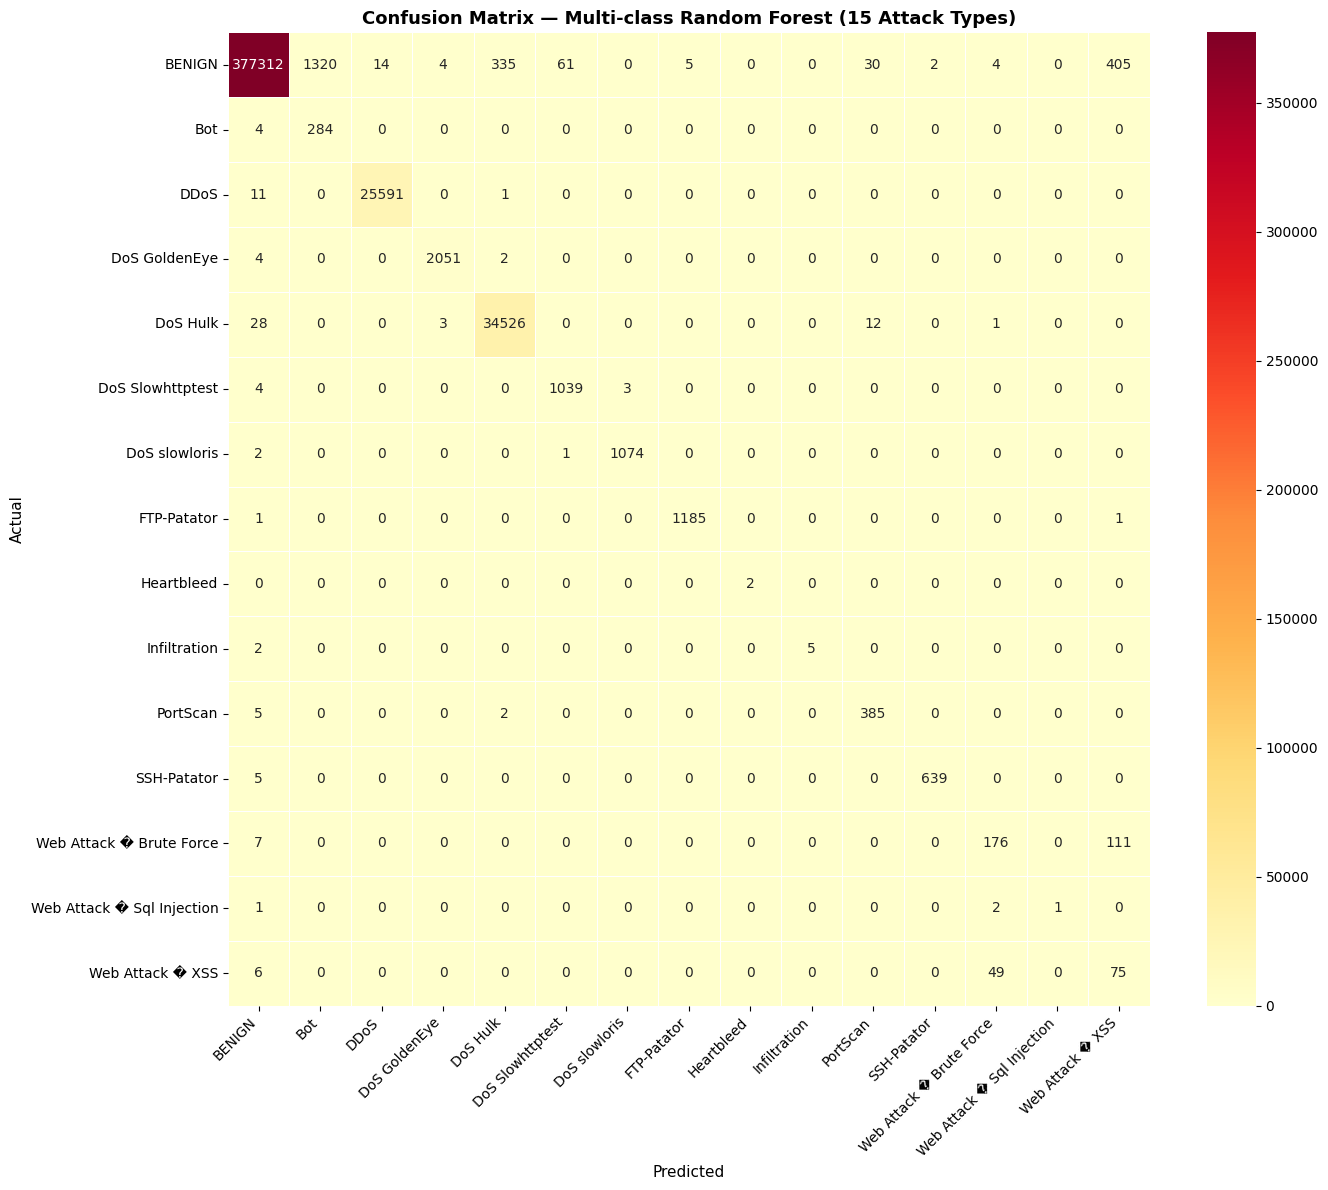

In [13]:
cm_multi = confusion_matrix(y_test_m, y_pred_multi)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            linewidths=0.5)
plt.title("Confusion Matrix — Multi-class Random Forest (15 Attack Types)", fontsize=13, fontweight='bold')
plt.ylabel("Actual", fontsize=11)
plt.xlabel("Predicted", fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/rf_multiclass_confusion.png", dpi=150)
plt.show()

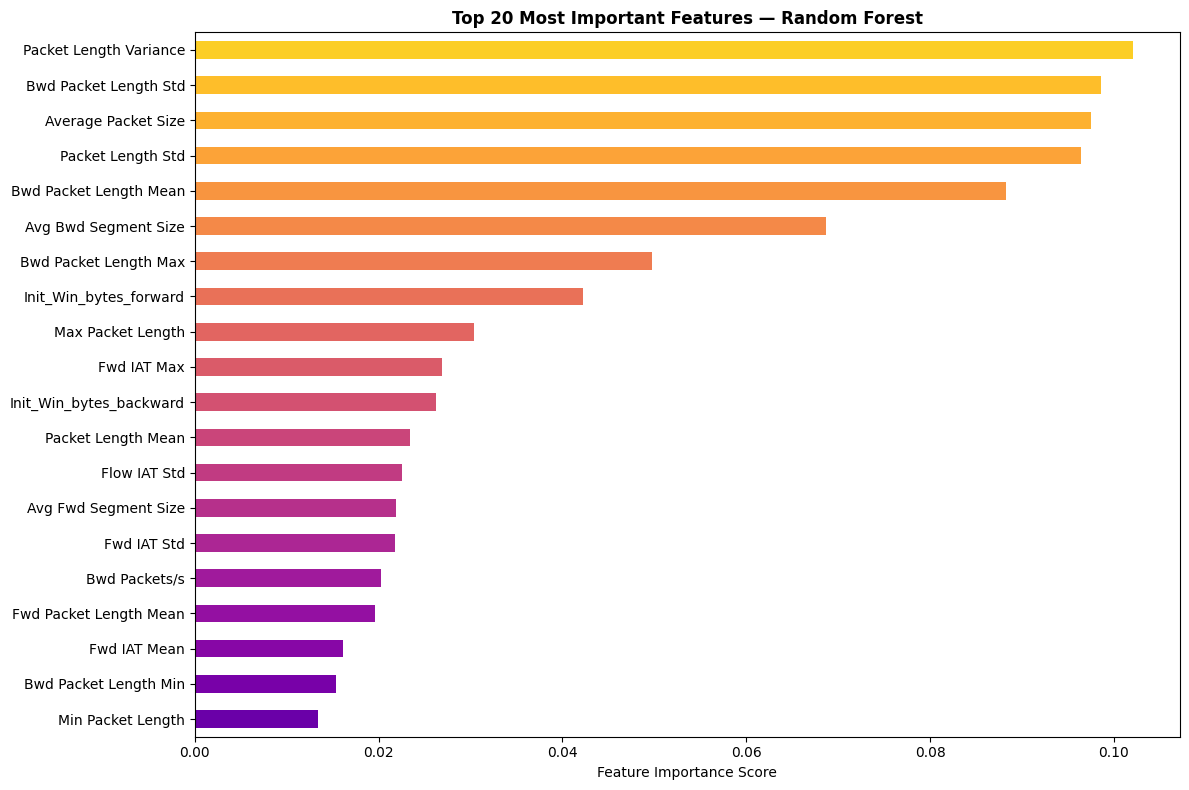

Top 10 most important features:
   1. Packet Length Variance                   0.1021
   2. Bwd Packet Length Std                    0.0986
   3. Average Packet Size                      0.0975
   4. Packet Length Std                        0.0964
   5. Bwd Packet Length Mean                   0.0883
   6. Avg Bwd Segment Size                     0.0687
   7. Bwd Packet Length Max                    0.0498
   8. Init_Win_bytes_forward                   0.0422
   9. Max Packet Length                        0.0304
  10. Fwd IAT Max                              0.0269


In [14]:
selected_features = joblib.load("../models/saved/selected_features.pkl")

importances = rf_binary.feature_importances_
feat_imp = pd.Series(importances, index=selected_features).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
colors = plt.cm.plasma(np.linspace(0.2, 0.9, 20))
feat_imp[:20].plot(kind='barh', color=colors[::-1])
plt.title("Top 20 Most Important Features — Random Forest", fontweight='bold')
plt.xlabel("Feature Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/rf_feature_importance.png", dpi=150)
plt.show()

print("Top 10 most important features:")
for i, (feat, score) in enumerate(feat_imp[:10].items(), 1):
    print(f"  {i:2d}. {feat:40s} {score:.4f}")

In [15]:
model_path = "../models/saved/"

joblib.dump(rf_binary, model_path + "rf_binary.pkl")
joblib.dump(rf_multi,  model_path + "rf_multi.pkl")
joblib.dump(xgb_binary, model_path + "xgb_binary.pkl")

print("✅ All models saved:")
for f in os.listdir(model_path):
    size = os.path.getsize(model_path + f) / (1024*1024)
    print(f"  {f:35s} {size:.1f} MB")

✅ All models saved:
  label_encoder.pkl                   0.0 MB
  rf_binary.pkl                       16.0 MB
  rf_multi.pkl                        58.9 MB
  scaler.pkl                          0.0 MB
  selected_features.pkl               0.0 MB
  xgb_binary.pkl                      0.5 MB


In [16]:
y_pred_test = rf_binary.predict(X_test)
y_prob_test = rf_binary.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  FINAL TEST SET RESULTS — Random Forest Binary")
print("=" * 55)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_test)*100:.2f}%")
print(f"  F1 Score  : {f1_score(y_test, y_pred_test)*100:.2f}%")
print(f"  Precision : {precision_score(y_test, y_pred_test)*100:.2f}%")
print(f"  Recall    : {recall_score(y_test, y_pred_test)*100:.2f}%")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob_test)*100:.2f}%")
print("=" * 55)
print("\n✅ Ready for Step 5: Anomaly Detection (Autoencoder)")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    1.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.9s finished


  FINAL TEST SET RESULTS — Random Forest Binary
  Accuracy  : 99.73%
  F1 Score  : 99.64%
  Precision : 99.55%
  Recall    : 99.72%
  ROC-AUC   : 100.00%

✅ Ready for Step 5: Anomaly Detection (Autoencoder)
